In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Copy of heart_disease.xlsx to Copy of heart_disease.xlsx


In [2]:
import pandas as pd
import numpy as np

In [3]:
heart_disease_df = pd.read_excel("Copy of heart_disease.xlsx", sheet_name='Heart_disease')

In [4]:
# Checking the structure, data types, and missing values
heart_disease_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
# Basic statistics for numerical columns
heart_disease_df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [6]:
# Checking for missing values
heart_disease_df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Checking for missing values
missing_values = heart_disease_df.isnull().sum()

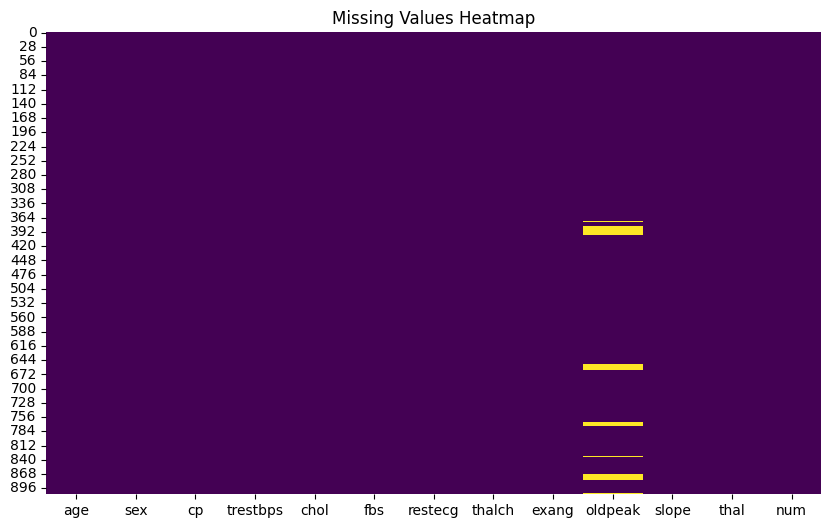

In [8]:
# Visualizing missing values as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heart_disease_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

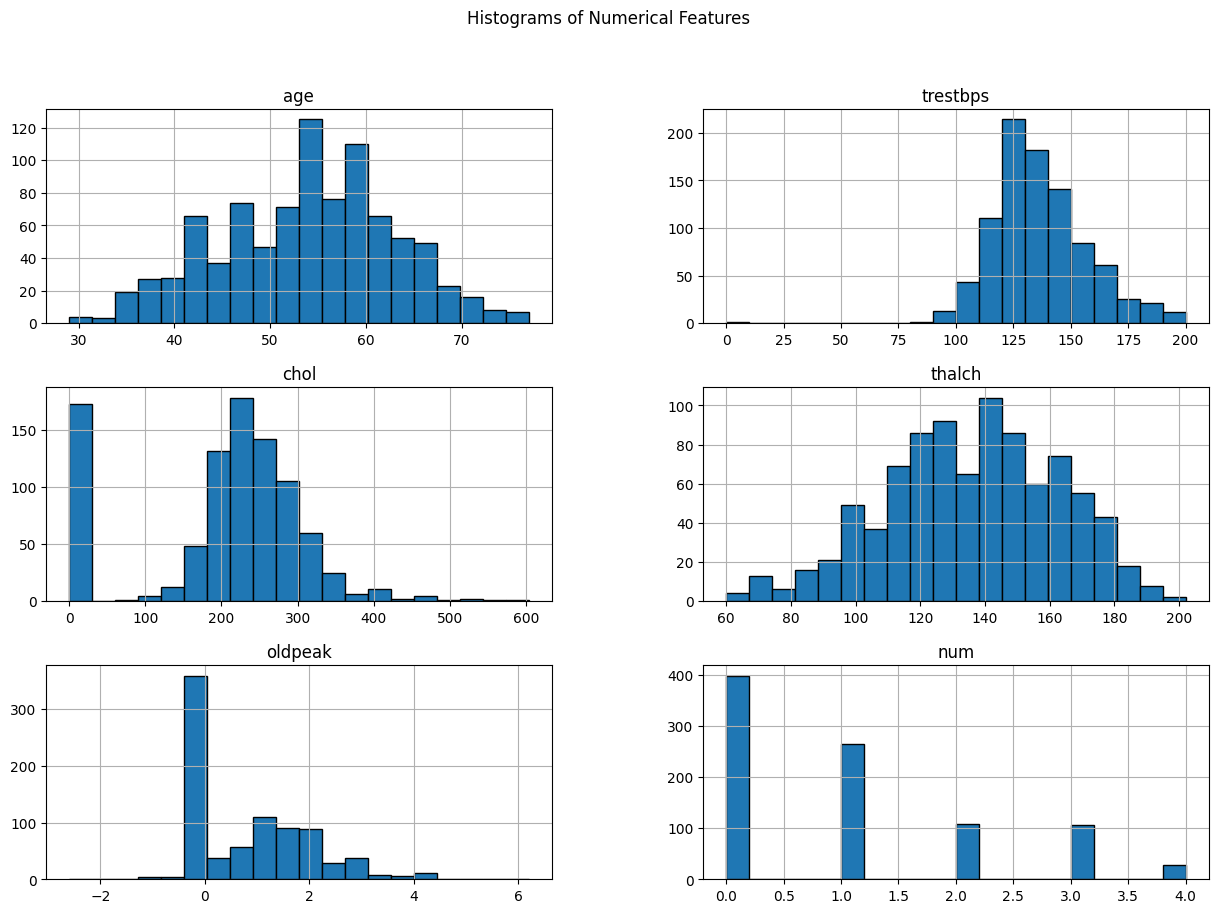

In [9]:
# Histograms for numerical features
heart_disease_df.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle('Histograms of Numerical Features')
plt.show()

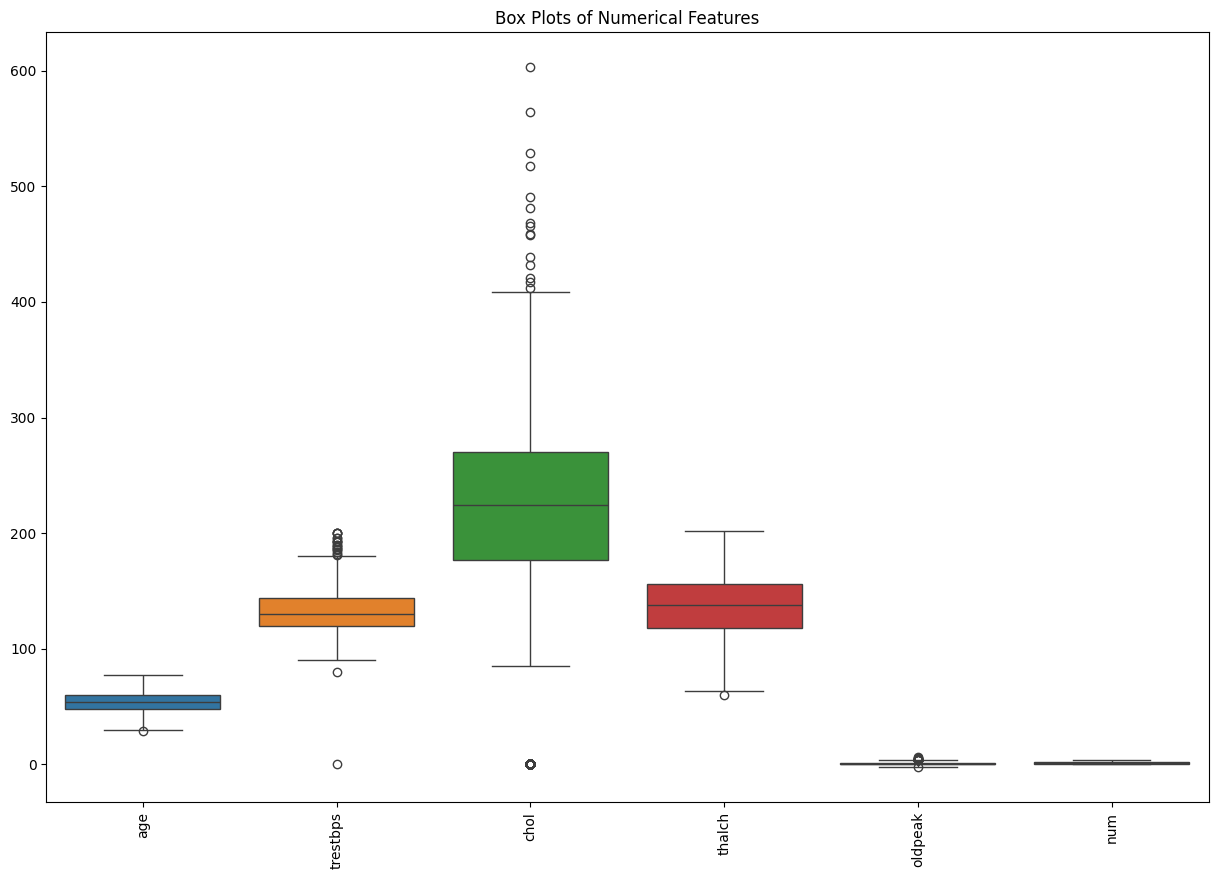

In [ ]:
# Box plots to detect outliers
plt.figure(figsize=(15, 10))
sns.boxplot(data=heart_disease_df.select_dtypes(include=['int64', 'float64']))
plt.title('Box Plots of Numerical Features')
plt.xticks(rotation=90)
plt.show()
//Improves query performance by eliminating unnecessary data.


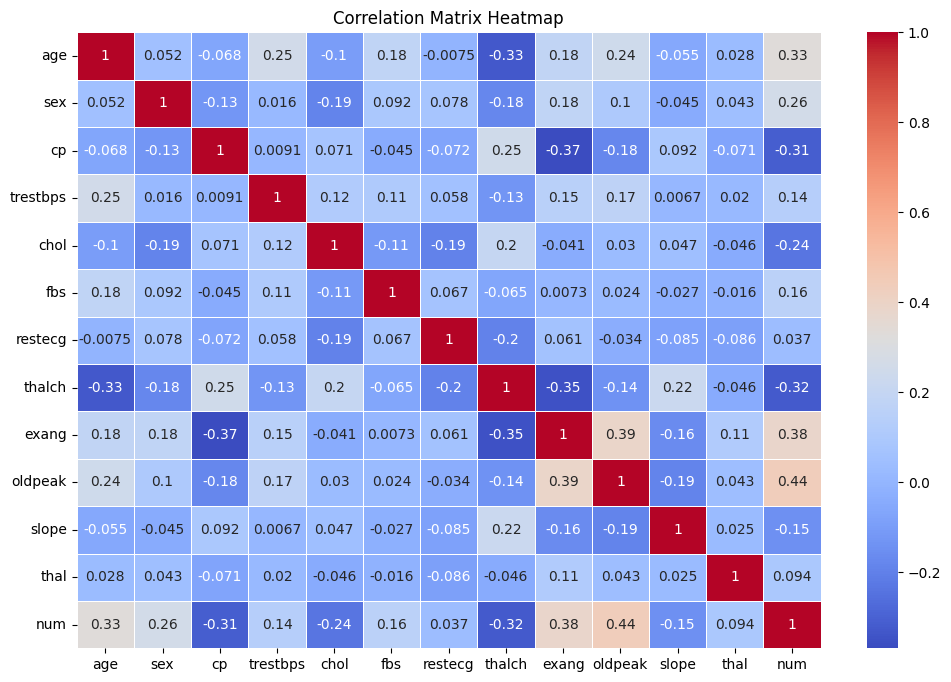

In [12]:
# Convert categorical columns to numeric values where necessary before correlation
heart_disease_numeric = heart_disease_df.copy()

# Convert 'sex', 'cp', 'restecg', 'exang', 'slope', 'thal' to numeric using one-hot encoding or label encoding
heart_disease_numeric['sex'] = heart_disease_numeric['sex'].map({'Male': 1, 'Female': 0})
heart_disease_numeric['cp'] = heart_disease_numeric['cp'].astype('category').cat.codes
heart_disease_numeric['restecg'] = heart_disease_numeric['restecg'].astype('category').cat.codes
heart_disease_numeric['exang'] = heart_disease_numeric['exang'].map({True: 1, False: 0})
heart_disease_numeric['slope'] = heart_disease_numeric['slope'].astype('category').cat.codes
heart_disease_numeric['thal'] = heart_disease_numeric['thal'].astype('category').cat.codes

# Now calculate the correlation matrix
correlation_matrix = heart_disease_numeric.corr()

# Visualizing the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Handle missing values (e.g., using mean imputation for 'oldpeak')
imputer = SimpleImputer(strategy='mean')
heart_disease_df['oldpeak'] = imputer.fit_transform(heart_disease_df[['oldpeak']])

In [14]:
#Encoding categorical variables (already handled in step 2)
heart_disease_df['sex'] = heart_disease_df['sex'].map({'Male': 1, 'Female': 0})
heart_disease_df['cp'] = heart_disease_df['cp'].astype('category').cat.codes
heart_disease_df['restecg'] = heart_disease_df['restecg'].astype('category').cat.codes
heart_disease_df['exang'] = heart_disease_df['exang'].map({True: 1, False: 0})
heart_disease_df['slope'] = heart_disease_df['slope'].astype('category').cat.codes
heart_disease_df['thal'] = heart_disease_df['thal'].astype('category').cat.codes

In [15]:
# Scaling numerical features
scaler = StandardScaler()
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
heart_disease_df[numerical_cols] = scaler.fit_transform(heart_disease_df[numerical_cols])

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Split the dataset into features and target variable
X = heart_disease_df.drop(columns='num')  # Features
y = heart_disease_df['num']  # Target (heart disease classification)

In [17]:
# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)

# Train the model on the training set
clf.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = clf.predict(X_test)

In [19]:
# Evaluate the model using different metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, clf.predict_proba(X_test), multi_class='ovr')

In [20]:
# Displaying metrics
accuracy, precision, recall, f1, roc_auc

(0.5164835164835165,
 0.5172411086754579,
 0.5164835164835165,
 0.5164667444887225,
 0.5968054745707126)

In [21]:
# Confusion matrix
confusion_matrix(y_test, y_pred)

array([[65, 13,  6,  2,  3],
       [17, 18,  5,  7,  1],
       [ 4,  6,  7,  4,  1],
       [ 3,  5,  3,  4,  2],
       [ 2,  1,  2,  1,  0]])

In [22]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameters to tune
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 2, 4]
}

In [23]:
# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid,
                           scoring='accuracy', cv=5, n_jobs=-1, verbose=1)


In [24]:
# Fit the model
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_

Fitting 5 folds for each of 90 candidates, totalling 450 fits


In [25]:
# Train the optimized model
best_clf = grid_search.best_estimator_

# Make predictions and evaluate the optimized model
y_pred_optimized = best_clf.predict(X_test)

In [26]:
# Evaluate using accuracy, precision, recall, F1-score, and ROC-AUC
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
precision_optimized = precision_score(y_test, y_pred_optimized, average='weighted')
recall_optimized = recall_score(y_test, y_pred_optimized, average='weighted')
f1_optimized = f1_score(y_test, y_pred_optimized, average='weighted')
roc_auc_optimized = roc_auc_score(y_test, best_clf.predict_proba(X_test), multi_class='ovr')

In [27]:
# Displaying optimized metrics
best_params, accuracy_optimized, precision_optimized, recall_optimized, f1_optimized, roc_auc_optimized

({'criterion': 'gini',
  'max_depth': 5,
  'min_samples_leaf': 4,
  'min_samples_split': 2},
 0.554945054945055,
 0.503171830834127,
 0.554945054945055,
 0.515635206751567,
 0.6989810382361876)

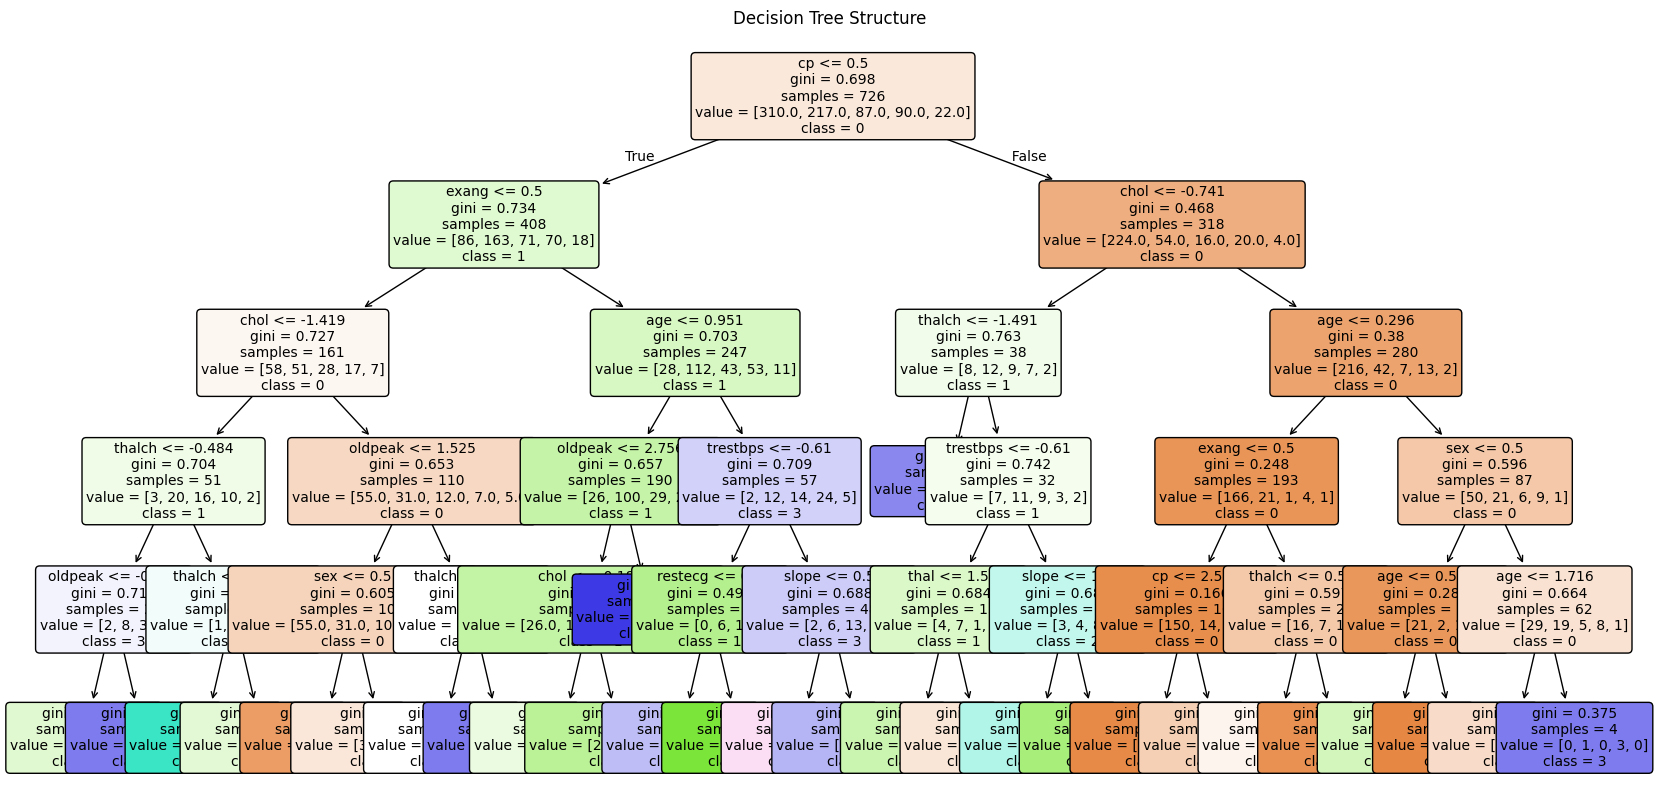

In [30]:
import matplotlib.pyplot as plt
from sklearn import tree

# Assuming `best_clf` is your trained decision tree model
# and `X` and `y` are your feature matrix and target vector, respectively.

# Convert class labels to a list of strings
class_names = [str(label) for label in set(y)]

# Visualize the decision tree structure
plt.figure(figsize=(20, 10))
tree.plot_tree(best_clf, feature_names=X.columns, class_names=class_names, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure")
plt.show()


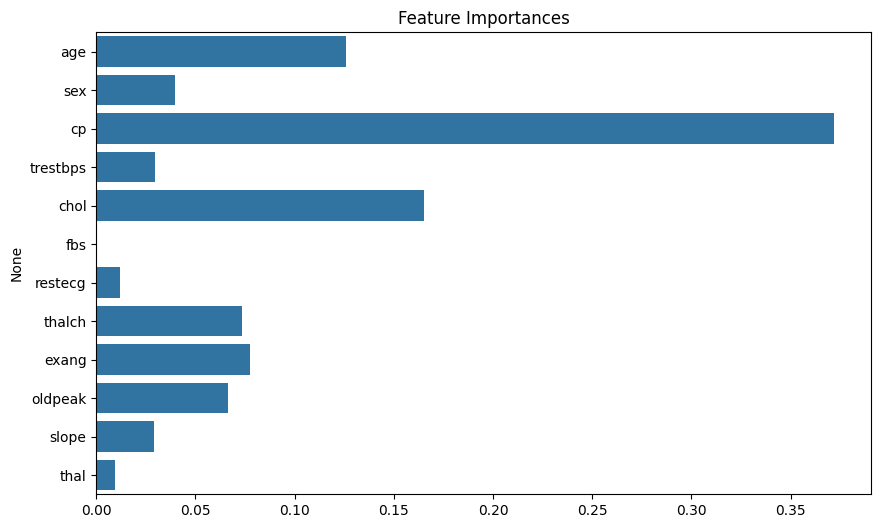

In [31]:
# Identify important features
feature_importances = best_clf.feature_importances_

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=X.columns)
plt.title('Feature Importances')
plt.show()

In [32]:
# Confusion matrix for further analysis
conf_matrix = confusion_matrix(y_test, y_pred_optimized)


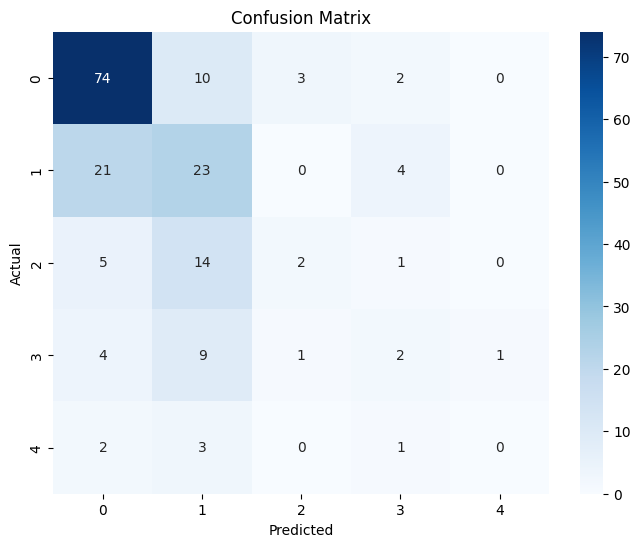

In [33]:
# Visualizing confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=set(y), yticklabels=set(y))
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [34]:
#1. Common Hyperparameters of Decision Tree Models
#Key hyperparameters include max_depth, which limits the tree's depth to prevent overfitting, and min_samples_split, which sets the minimum samples
# needed to split a node. min_samples_leaf ensures leaf nodes have a minimum number of samples to smooth the model. Additionally, max_features controls the number of
#features considered for splitting, while criterion determines the quality measure for splits, influencing tree structure.

In [35]:
#2. Difference Between Label Encoding and One-Hot Encoding
#Label encoding assigns a unique integer to each category, making it suitable for ordinal data where order matters.
#In contrast, one-hot encoding creates binary columns for each category, ideal for nominal data without inherent order.
# While label encoding can mislead algorithms by implying relationships, one-hot encoding prevents such issues, treating each category independently.